In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Part 2

In [ ]:
import cv2
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import tensorflow as tf

from sklearn.metrics import accuracy_score
from collections import defaultdict


In [ ]:
# Set your base data directory
data_path = '/content/drive/MyDrive/ME 592/HW3/Data_Preparation_112/data/videos'

# Extract random frames from each video
def extract_random_frames(video_path, n_frames=5, resize_dim=(112, 112)):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count < 1:
        return []

    selected_frames = sorted(random.sample(range(frame_count), min(n_frames, frame_count)))
    frames = []

    for i in range(frame_count):
        success, frame = cap.read()
        if not success:
            break
        if i in selected_frames:
            frame = cv2.resize(frame, resize_dim)
            frames.append(frame)

    cap.release()
    return frames

# Prepare the data for training/testing
def prepare_data(split='train', n_frames=5):
    split_path = os.path.join(data_path, split)
    X, y, video_ids = [], [], []
    label_names = sorted(os.listdir(split_path))

    for label_idx, label_name in enumerate(label_names):
        label_path = os.path.join(split_path, label_name)
        video_files = []
        for ext in ('*.mp4', '*.mov', '*.avi'):
            video_files.extend(glob(os.path.join(label_path, ext)))

        print(f"Found {len(video_files)} videos in {split}/{label_name}")

        for video_file in tqdm(video_files, desc=f"{split} - {label_name}"):
            frames = extract_random_frames(video_file, n_frames=n_frames)
            if frames:
                X.extend(frames)
                y.extend([label_idx] * len(frames))
                video_ids.extend([video_file] * len(frames))  # track which frames belong to which video

    return np.array(X), np.array(y), label_names, video_ids


In [ ]:
# Load data
X_train, y_train, label_names, video_ids_train = prepare_data('train', n_frames=5)
X_val, y_val, _, video_ids_val = prepare_data('val', n_frames=5)
X_test, y_test, _, video_ids_test = prepare_data('test', n_frames=5)

# Normalize data
X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=len(label_names))
y_val = to_categorical(y_val, num_classes=len(label_names))
y_test = to_categorical(y_test, num_classes=len(label_names))

Found 5 videos in train/Extra Activities


train - Extra Activities: 100%|██████████| 5/5 [00:00<00:00, 30.96it/s]


Found 61 videos in train/Grazing


train - Grazing: 100%|██████████| 61/61 [00:03<00:00, 16.22it/s]


Found 47 videos in train/Running


...

test - Sitting: 100%|██████████| 21/21 [00:00<00:00, 32.91it/s]


Found 24 videos in test/Standing


test - Standing: 100%|██████████| 24/24 [00:00<00:00, 25.63it/s]


Found 8 videos in test/Walking


test - Walking: 100%|██████████| 8/8 [00:00<00:00, 28.52it/s]


In [ ]:
def build_2d_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Initialize model
model = build_2d_cnn((112, 112, 3), len(label_names))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.2144 - loss: 1.7109 - val_accuracy: 0.2927 - val_loss: 1.6450
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2397 - loss: 1.6447 - val_accuracy: 0.2976 - val_loss: 1.5421
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3945 - loss: 1.5223 - val_accuracy: 0.5366 - val_loss: 1.3702
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5051 - loss: 1.2345 - val_accuracy: 0.5317 - val_loss: 1.2224
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5377 - loss: 1.0794 - val_accuracy: 0.3512 - val_loss: 1.2498
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5431 - loss: 0.9867 - val_accuracy: 0.5122 - val_loss: 1.0995
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5730 - loss: 0.9799 - val_accuracy: 0.4780 - val_loss: 1.1613
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5936 - loss: 0.9240 - val_accuracy: 0.4878 - 

In [ ]:
# Predict probabilities for each frame and average predictions per video
def evaluate_avg_predictions(model, X_test, y_test, video_ids):
    frame_probs = model.predict(X_test)
    frame_labels = np.argmax(y_test, axis=1)  # Ground truth (per-frame)

    # Group predictions and ground truths by video
    video_pred_dict = defaultdict(list)
    video_true_dict = {}

    for prob, label, vid in zip(frame_probs, frame_labels, video_ids):
        video_pred_dict[vid].append(prob)
        video_true_dict[vid] = label  # All frames from same video have same label

    # Average predictions per video and get predicted class
    video_preds = {}
    for vid, probs in video_pred_dict.items():
        avg_prob = np.mean(probs, axis=0)
        video_preds[vid] = np.argmax(avg_prob)

    # Get video-level true and predicted labels
    y_video_true = [video_true_dict[vid] for vid in video_preds.keys()]
    y_video_pred = [video_preds[vid] for vid in video_preds.keys()]

    # Report video-level accuracy
    video_acc = accuracy_score(y_video_true, y_video_pred)
    print(f"🎬 Video-level Accuracy (via averaging predictions): {video_acc:.4f}")

    # Classification report
    print(classification_report(y_video_true, y_video_pred, target_names=label_names))


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
🎬 Video-level Accuracy (via averaging predictions): 0.6024
                  precision    recall  f1-score   support

Extra Activities       0.00      0.00      0.00         1
         Grazing       0.46      0.72      0.57        18
         Running       0.57      0.73      0.64        11
         Sitting       0.71      0.57      0.63        21
        Standing       0.71      0.71      0.71        24
         Walking       0.00      0.00      0.00         8

        accuracy                           0.60        83
       macro avg       0.41      0.45      0.42        83
    weighted avg       0.56      0.60      0.57        83



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


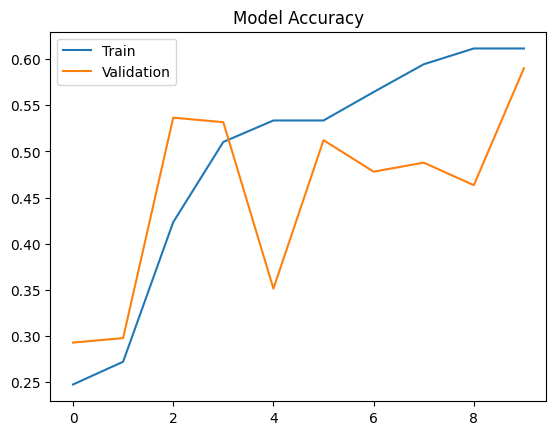

In [ ]:
# Evaluate on test data
evaluate_avg_predictions(model, X_test, y_test, video_ids_test)

# Plot training history
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Tradeoffs of frame sampling

Tradeoffs of frame sampling: more samples can lead to better generalization and higher prediction accuracy but at the cost of a higher computational cost.

# Part 3

Functions for extracting random clips of 16 consecutive frames from the same video and preparing the data for the 3D CNN by first extracting random clips in train, test, and val, then resizing the frames to 112x112 pixels, next one-hot encoding the labels, and finally returns the processed data.

In [ ]:
# Function to extract a random 16-frame clip from a video
def extract_random_clips(video_path, clip_length=16, resize_dim=(112, 112)):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count < clip_length:
        cap.release()
        return []

    start_idx = random.randint(0, frame_count - clip_length)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_idx)

    clip = []
    for _ in range(clip_length):
        success, frame = cap.read()
        if not success:
            break
        frame = cv2.resize(frame, resize_dim)
        clip.append(frame)

    cap.release()
    if len(clip) == clip_length:
        return [np.array(clip)]  # shape: (16, 112, 112, 3)
    else:
        return []

# Prepare dataset for 3D CNN
def prepare_data_for_3dcnn(split='train', clip_length=16):
    split_path = os.path.join(data_path, split)
    X, y, video_ids = [], [], []
    label_names = sorted(os.listdir(split_path))

    for label_idx, label_name in enumerate(label_names):
        label_path = os.path.join(split_path, label_name)
        video_files = []
        for ext in ('*.mp4', '*.mov', '*.avi'):
            video_files.extend(glob(os.path.join(label_path, ext)))

        print(f"Found {len(video_files)} videos in {split}/{label_name}")

        for video_file in tqdm(video_files, desc=f"{split} - {label_name}"):
            clips = extract_random_clips(video_file, clip_length=clip_length)
            for clip in clips:
                X.append(clip)
                y.append(label_idx)
                video_ids.append(video_file)

    X = np.stack(X) if len(X) > 0 else np.array([])
    y = to_categorical(np.array(y)) if len(y) > 0 else np.array([])
    return X, y, label_names, video_ids

# Load datasets
X_train, y_train, label_names, _ = prepare_data_for_3dcnn('train', clip_length=16)
X_val, y_val, _, _ = prepare_data_for_3dcnn('val', clip_length=16)
X_test, y_test, _, _ = prepare_data_for_3dcnn('test', clip_length=16)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Found 5 videos in train/Extra Activities


train - Extra Activities: 100%|██████████| 5/5 [00:00<00:00, 33.55it/s]


Found 61 videos in train/Grazing


train - Grazing: 100%|██████████| 61/61 [00:01<00:00, 42.55it/s]


Found 47 videos in train/Running


...

Found 24 videos in test/Standing


test - Standing: 100%|██████████| 24/24 [00:00<00:00, 66.50it/s]


Found 8 videos in test/Walking


test - Walking: 100%|██████████| 8/8 [00:00<00:00, 65.03it/s]

Train shape: (292, 16, 112, 112, 3)
Validation shape: (41, 16, 112, 112, 3)
Test shape: (83, 16, 112, 112, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization

# Define a 3D CNN model
model_3d = Sequential([
    Conv3D(32, kernel_size=(3, 3, 3), activation='relu', input_shape=(16, 112, 112, 3), padding='same'),
    MaxPooling3D(pool_size=(2, 2, 2)),
    BatchNormalization(),

    Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'),
    MaxPooling3D(pool_size=(2, 2, 2)),
    BatchNormalization(),

    Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same'),
    MaxPooling3D(pool_size=(2, 2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(label_names), activation='softmax')
])

model_3d.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history2 = model_3d.fit(
    X_train, y_train,
    batch_size=8,
    epochs=10,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 0.3199 - loss: 20.1816 - val_accuracy: 0.2927 - val_loss: 817.1333
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.4497 - loss: 6.3935 - val_accuracy: 0.2683 - val_loss: 281.2304
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5333 - loss: 2.0069 - val_accuracy: 0.2927 - val_loss: 123.6103
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.4891 - loss: 1.3627 - val_accuracy: 0.4878 - val_loss: 4.9360
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5201 - loss: 1.0864 - val_accuracy: 0.5122 - val_loss: 10.1925
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5878 - loss: 0.9428 - val_accuracy: 0.5122 - val_loss: 2.5787
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6152 - loss: 1.1533 - val_accuracy: 0.5366 - val_loss: 3.3394
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6214 - loss: 0.9795 - val_accuracy: 

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6775 - loss: 1.9197
3D CNN Test Accuracy: 0.6988
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step
Classification Report for 3D CNN:
                  precision    recall  f1-score   support

Extra Activities       0.00      0.00      0.00         1
         Grazing       0.75      0.50      0.60        18
         Running       0.50      0.82      0.62        11
         Sitting       0.83      0.71      0.77        21
        Standing       0.75      1.00      0.86        24
         Walking       0.33      0.12      0.18         8

        accuracy                           0.70        83
       macro avg       0.53      0.53      0.50        83
    weighted avg       0.69      0.70      0.67        83



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


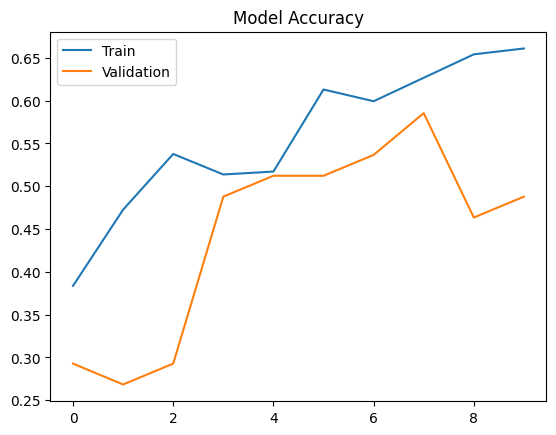

In [ ]:
# Evaluate 3D CNN
test_loss_3d, test_acc_3d = model_3d.evaluate(X_test, y_test)
print(f"3D CNN Test Accuracy: {test_acc_3d:.4f}")

y_pred_3d = model_3d.predict(X_test)

y_pred_3d_classes = np.argmax(y_pred_3d, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report for 3D CNN:")
print(classification_report(y_true, y_pred_3d_classes, target_names=label_names))

# plot train history for 3D CNN
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Challenges

Challenges: We needed to get the input dimensions of to the 3D CNN in the form of (number of samples, number of consecutive frames per clip (set to 16), height (set to 112), width (set to 112), number of channels (3 for RGB)in order to train the model which was a challenge. Another challenge is that 3D CNNs are even more computationally expensive than 2D CNNs which is why we used shorter clips and smaller resolutions for the 3D CNNs to work without taking too much time (more than a few minutes).

# 4

In [ ]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

#Load ResNet50 pretrained on ImageNet
base_model = ResNet101(include_top=False, pooling='avg', input_shape=(112, 112, 3))  # Average pooling to get fixed-size output
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Function to extract frame embeddings using ResNet50
def extract_frame_embeddings(clip):
    clip = np.array([preprocess_input(f.astype(np.float32)) for f in clip])  # Preprocess each frame
    embeddings = feature_extractor.predict(clip)  # Predict embeddings
    return embeddings  # Shape: (clip_length, embedding_dim)

# Prepare training sequences and labels
X_seq, y_seq = [], []

for clip, label in zip(X_train, y_train):
    embeddings = extract_frame_embeddings(clip)  # shape: (16, 2048) where 16 is number of frames
    X_seq.append(embeddings)  # Add the embeddings to the sequence list
    y_seq.append(label)  # Add corresponding label (one-hot encoded)

X_seq = np.array(X_seq)  # shape: (num_clips, 16, 2048)
y_seq = np.array(y_seq)  # shape: (num_clips, num_classes)

# Prepare validation sequences and labels (similar to training data)
X_val_seq, y_val_seq = [], []

for clip, label in zip(X_val, y_val):
    embeddings = extract_frame_embeddings(clip)  # shape: (16, 2048) where 16 is number of frames
    X_val_seq.append(embeddings)  # Add the embeddings to the validation sequence list
    y_val_seq.append(label)  # Add corresponding label (one-hot encoded)

X_val_seq = np.array(X_val_seq)  # shape: (num_val_clips, 16, 2048)
y_val_seq = np.array(y_val_seq)  # shape: (num_val_clips, num_classes)



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
model_lstm = Sequential([
    LSTM(128, return_sequences=False, input_shape=(16, 2048)),  # LSTM with input shape of (16, 2048)
    Dropout(0.3),
    Dense(len(label_names), activation='softmax')  # Adjust len(label_names) to match the number of classes
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with early stopping
history3 = model_lstm.fit(
    X_seq, y_seq,
    validation_data=(X_val_seq, y_val_seq),  # Use validation data during training
    shuffle=True,
    epochs=50,
    batch_size=32,
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4066 - loss: 1.4581 - val_accuracy: 0.6585 - val_loss: 0.9547
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7313 - loss: 0.7993 - val_accuracy: 0.7317 - val_loss: 0.8005
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7656 - loss: 0.5718 - val_accuracy: 0.6585 - val_loss: 0.8088
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7995 - loss: 0.5267 - val_accuracy: 0.6585 - val_loss: 0.7449
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8290 - loss: 0.4342 - val_accuracy: 0.6829 - val_loss: 0.8407
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8258 - loss: 0.4229 - val_accuracy: 0.7317 - val_loss: 0.7604
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8571 - loss: 0.3585 - val_accuracy: 0.7805 - val_loss: 0.7547
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8649 - loss: 0.3113 - val_accuracy: 0.7561 - val_loss: 0.

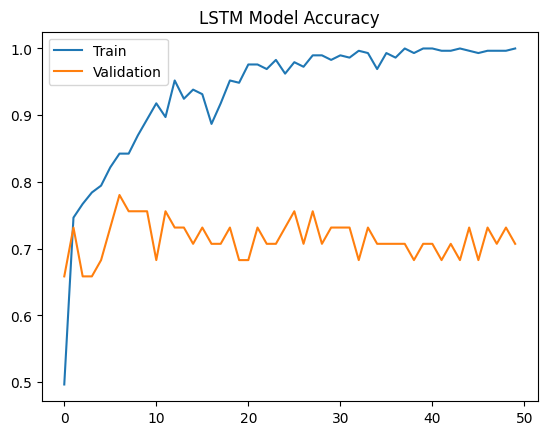

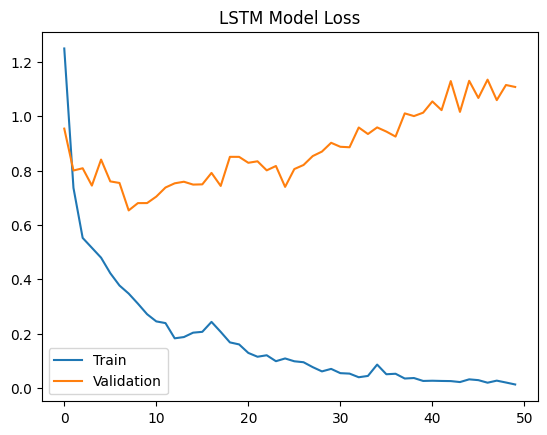

Extracting test embeddings:   0%|          | 0/83 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


Extracting test embeddings:   1%|          | 1/83 [00:00<00:16,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


Extracting test embeddings:   2%|▏         | 2/83 [00:00<00:15,  5.07it/s]

...

Extracting test embeddings:  99%|█████████▉| 82/83 [00:13<00:00,  5.65it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


Extracting test embeddings: 100%|██████████| 83/83 [00:13<00:00,  6.13it/s]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7627 - loss: 0.9031

📊 LSTM Test Accuracy: 0.7831
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Classification Report for LSTM on Test Set:
                  precision    recall  f1-score   support

Extra Activities       0.00      0.00      0.00         1
         Grazing       0.81      0.72      0.76        18
         Running       0.73      0.73      0.73        11
         Sitting       0.72      0.86      0.78        21
        Standing       0.91      0.88      0.89        24
         Walking       0.62      0.62      0.62         8

        accuracy                           0.78        83
       macro avg       0.63      0.63      0.63        83
    weighted avg       0.78      0.78      0.78        83



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Plot training and validation accuracy
plt.plot(history3.history['accuracy'], label='Train')
plt.plot(history3.history['val_accuracy'], label='Validation')
plt.legend()
plt.title('LSTM Model Accuracy')
plt.show()

# Plot training and validation loss
plt.plot(history3.history['loss'], label='Train')
plt.plot(history3.history['val_loss'], label='Validation')
plt.legend()
plt.title('LSTM Model Loss')
plt.show()

# Evaluate on the Test Set
X_test_seq, y_test_seq = [], []
for clip, label in tqdm(zip(X_test, y_test), total=len(X_test), desc='Extracting test embeddings'):
    embeddings = extract_frame_embeddings(clip)
    X_test_seq.append(embeddings)  # Shape: (16, embedding_dim)
    y_test_seq.append(label)

X_test_seq = np.array(X_test_seq)  # shape: (num_clips, 16, embedding_dim)
y_test_seq = np.array(y_test_seq)  # shape: (num_clips, num_classes)

# Evaluate the model on the test set
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test_seq, y_test_seq)
print(f"\n📊 LSTM Test Accuracy: {test_acc_lstm:.4f}")

# Predict and generate classification report
y_pred_test_lstm = model_lstm.predict(X_test_seq)
print("Classification Report for LSTM on Test Set:")
print(classification_report(
    np.argmax(y_test_seq, axis=1),  # Convert one-hot encoded to class index
    np.argmax(y_pred_test_lstm, axis=1),  # Predicted class indices
    target_names=label_names  # Label names for classes
))

# Comparison of results

Using LSTM with pretrained 2D CNN to get frame embeddings allows the model to get the temporal dependencies between frames without the computational cost of 3D CNNs as in Part 3. This temporal information is not found using only 2D CNNs as in Part 2. Part 4 gave the highest test accuracy out of Part 2 and Part 3.